In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape


(8807, 12)

In [4]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# **Dropping**

In [7]:
df = df.drop(['director', 'cast', 
              'description', 'show_id'], 
              axis=1)

print("Dropped ✅")
print(df.shape)

Dropped ✅
(8807, 8)


# **Filling**

In [8]:
df['country'] = df['country'].fillna('Unknown')

df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

print("Missing values fixed ✅")
print(df.isnull().sum())

Missing values fixed ✅
type            0
title           0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64


In [9]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8807 non-null   object
 1   title         8807 non-null   object
 2   country       8807 non-null   object
 3   date_added    8807 non-null   object
 4   release_year  8807 non-null   int64 
 5   rating        8807 non-null   object
 6   duration      8807 non-null   object
 7   listed_in     8807 non-null   object
dtypes: int64(1), object(7)
memory usage: 550.6+ KB
None
      type                  title        country          date_added  \
0    Movie   Dick Johnson Is Dead  United States  September 25, 2021   
1  TV Show          Blood & Water   South Africa  September 24, 2021   
2  TV Show              Ganglands        Unknown  September 24, 2021   
3  TV Show  Jailbirds New Orleans        Unknown  September 24, 2021   
4  TV Show           Kota Factory          India  Septemb

# **Converting**

In [10]:
df['type'] = df['type'].map({'Movie': 0, 'TV Show': 1})

print(df['type'].value_counts())

type
0    6131
1    2676
Name: count, dtype: int64


In [11]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df = df.drop('date_added', axis=1)

print("Date extracted ✅")
print(df[['year_added', 'month_added']].head())

Date extracted ✅
   year_added  month_added
0        2021            9
1        2021            9
2        2021            9
3        2021            9
4        2021            9


In [12]:
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(int)
df['duration_type'] = df['duration'].str.extract(r'([a-zA-Z]+)')


df['duration_type'] = df['duration_type'].map(
    {'min': 0, 'Season': 1, 'Seasons': 1}
)


df = df.drop('duration', axis=1)

print("Duration done ✅")
print(df[['duration_value', 'duration_type']].head(10))

Duration done ✅
   duration_value  duration_type
0              90              0
1               2              1
2               1              1
3               1              1
4               2              1
5               1              1
6              91              0
7             125              0
8               9              1
9             104              0


In [13]:
print(df['rating'].value_counts())

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


***removing wrong values then fixing,converting it to numeric***

In [14]:
# Step 1 - Remove wrong rows
df = df[~df['rating'].isin(['74 min', '84 min', '66 min'])]

# Step 2 - Convert to numbers immediately
rating_map = {
    'G': 0, 'PG': 1, 'PG-13': 2,
    'R': 3, 'NC-17': 4, 'TV-Y': 5,
    'TV-Y7': 6, 'TV-Y7-FV': 7,
    'TV-G': 8, 'TV-PG': 9,
    'TV-14': 10, 'TV-MA': 11,
    'NR': 12, 'UR': 12
}

df['rating'] = df['rating'].map(rating_map)

print("Rating done ✅")
print(df['rating'].value_counts())

Rating done ✅
rating
11    3211
10    2160
9      863
3      799
2      490
6      334
5      307
1      287
8      220
12      83
0       41
7        6
4        3
Name: count, dtype: int64


In [15]:
print(df['country'].nunique())
print(df['country'].value_counts().head(10))


749
country
United States     2815
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [16]:
top_countries = df['country'].value_counts().head(10).index
df['country'] = df['country'].apply(
    lambda x: x if x in top_countries else 'Other'
)
print(df['country'].value_counts())

country
United States     2815
Other             2763
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [17]:
country_map = {
    'United States': 0,
    'India': 1,
    'Unknown': 2,
    'United Kingdom': 3,
    'Japan': 4,
    'South Korea': 5,
    'Canada': 6,
    'Spain': 7,
    'France': 8,
    'Mexico': 9,
    'Other': 10
}

df['country'] = df['country'].map(country_map)

print("Country done ✅")
print(df['country'].value_counts())

Country done ✅
country
0     2815
10    2763
1      972
2      831
3      419
4      245
5      199
6      181
7      145
8      124
9      110
Name: count, dtype: int64


In [18]:
print(df['listed_in'].nunique())
print(df['listed_in'].value_counts().head(10))

514
listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


In [19]:
# Step 1 - Extract main genre
df['main_genre'] = df['listed_in'].str.split(',').str[0].str.strip()

# Step 2 - Keep top 10, rest = Other
top_genres = df['main_genre'].value_counts().head(10).index
df['main_genre'] = df['main_genre'].apply(
    lambda x: x if x in top_genres else 'Other'
)

# Step 3 - Map to numbers
genre_map = {
    'Dramas': 0,
    'Comedies': 1,
    'Action & Adventure': 2,
    'Documentaries': 3,
    'International TV Shows': 4,
    'Children & Family Movies': 5,
    'Crime TV Shows': 6,
    "Kids' TV": 7,
    'Stand-Up Comedy': 8,
    'Horror Movies': 9,
    'Other': 10
}

df['main_genre'] = df['main_genre'].map(genre_map)

# Step 4 - Fix float to int
df['main_genre'] = df['main_genre'].astype(int)

# Step 5 - Drop original column
df = df.drop('listed_in', axis=1)

print("Genre done ✅")
print(df['main_genre'].value_counts())
print(df['main_genre'].isnull().sum())

Genre done ✅
main_genre
0     1600
10    1531
1     1210
2      859
3      829
4      774
5      605
6      399
7      388
8      334
9      275
Name: count, dtype: int64
0


In [20]:
print(df.info())
print("----------")
print(df.head())
print("----------")
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 8804 entries, 0 to 8806
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   type            8804 non-null   int64 
 1   title           8804 non-null   object
 2   country         8804 non-null   int64 
 3   release_year    8804 non-null   int64 
 4   rating          8804 non-null   int64 
 5   year_added      8804 non-null   int32 
 6   month_added     8804 non-null   int32 
 7   duration_value  8804 non-null   int64 
 8   duration_type   8804 non-null   int64 
 9   main_genre      8804 non-null   int64 
dtypes: int32(2), int64(7), object(1)
memory usage: 687.8+ KB
None
----------
   type                  title  country  release_year  rating  year_added  \
0     0   Dick Johnson Is Dead        0          2020       2        2021   
1     1          Blood & Water       10          2021      11        2021   
2     1              Ganglands        2          2021      11

# **EDA**

***Movies vs TV Shows ratio?***

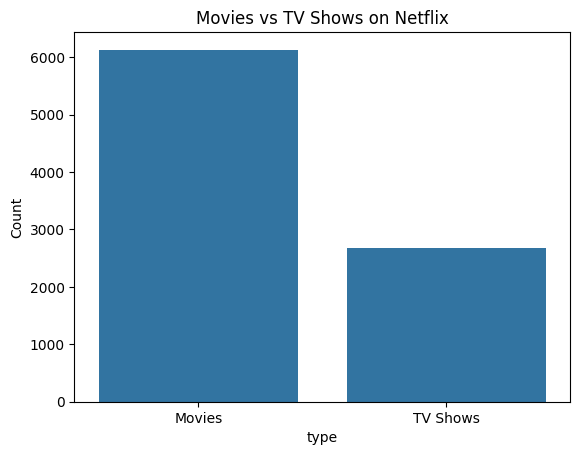

In [21]:

sns.countplot(x='type', data=df)
plt.title('Movies vs TV Shows on Netflix')
plt.xticks([0, 1], ['Movies', 'TV Shows'])
plt.ylabel('Count')
plt.show()

***Which country produces most content?***

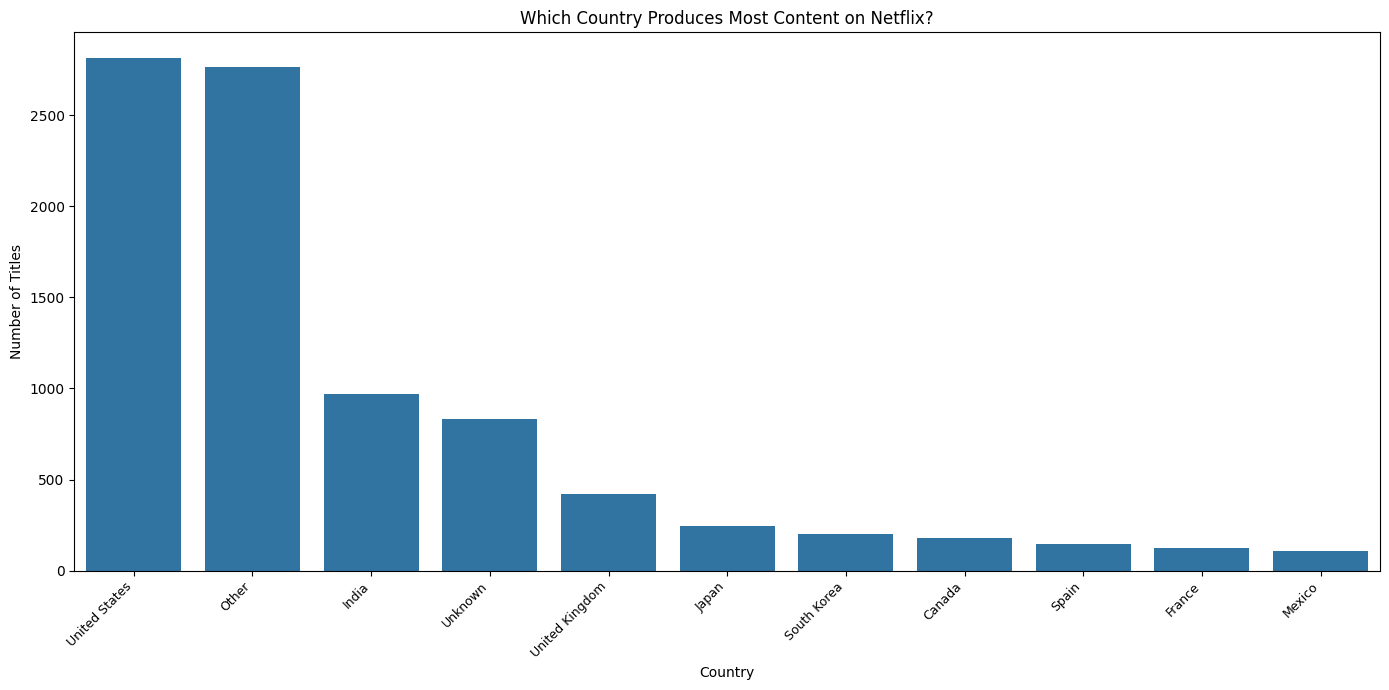

In [22]:
country_map_reverse = {
    0: 'United States',
    1: 'India',
    2: 'Unknown',
    3: 'United Kingdom',
    4: 'Japan',
    5: 'South Korea',
    6: 'Canada',
    7: 'Spain',
    8: 'France',
    9: 'Mexico',
    10: 'Other'
}
country_counts = df['country'].value_counts()
country_counts.index = country_counts.index.map(country_map_reverse)

plt.figure(figsize=(14, 7))
sns.barplot(x=country_counts.index, y=country_counts.values)
plt.title('Which Country Produces Most Content on Netflix?')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45 ,ha='right', fontsize=9)
plt.tight_layout()
plt.show()

***Which genre is most popular?***

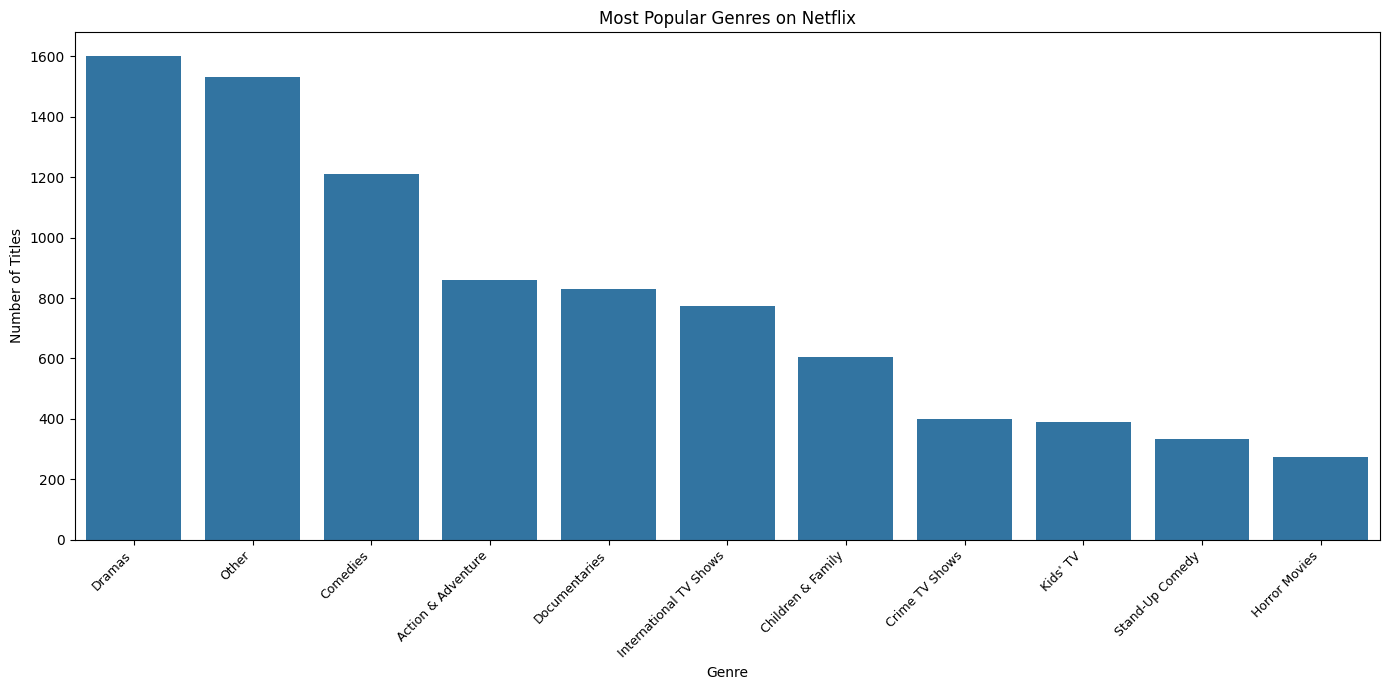

In [23]:
genre_map_reverse = {
    0: 'Dramas',
    1: 'Comedies',
    2: 'Action & Adventure',
    3: 'Documentaries',
    4: 'International TV Shows',
    5: 'Children & Family',
    6: 'Crime TV Shows',
    7: "Kids' TV",
    8: 'Stand-Up Comedy',
    9: 'Horror Movies',
    10: 'Other'
}

genre_counts = df['main_genre'].value_counts()
genre_counts.index = genre_counts.index.map(genre_map_reverse)

plt.figure(figsize=(14, 7))
sns.barplot(x=genre_counts.index, y=genre_counts.values)
plt.title('Most Popular Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

***Content Added Per Year***

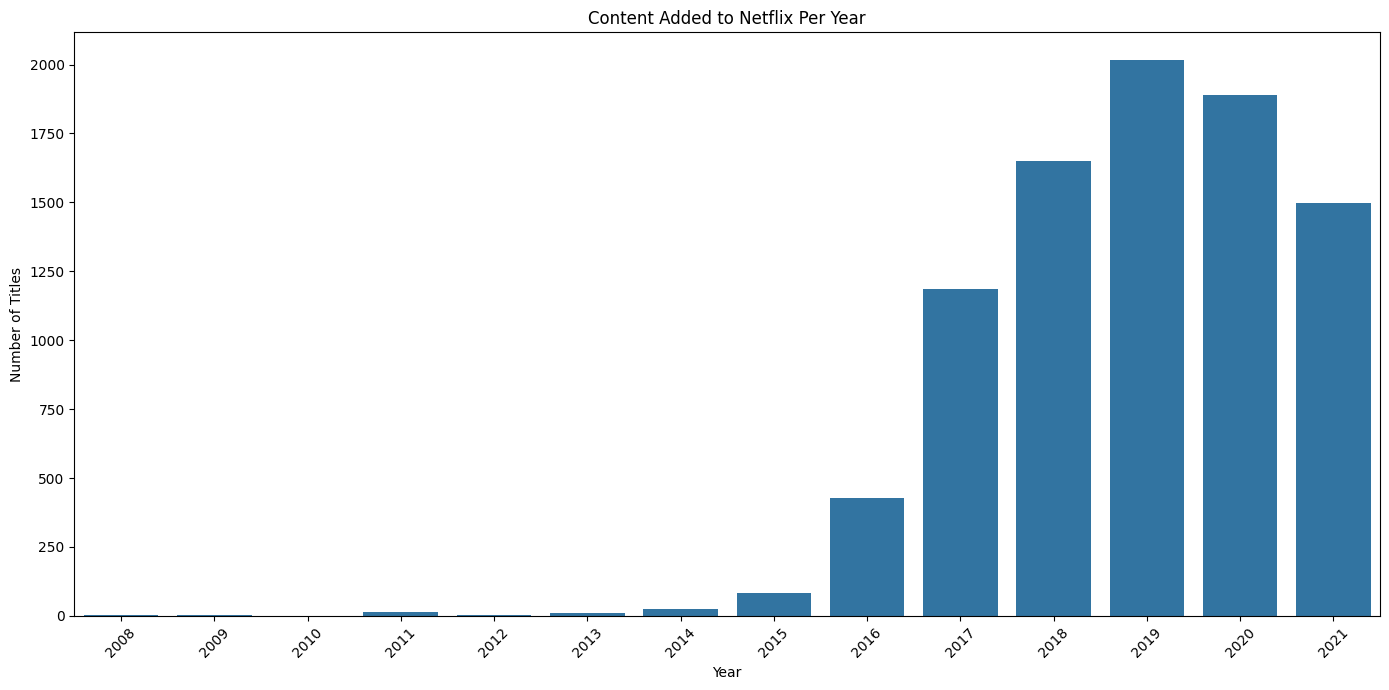

In [24]:
plt.figure(figsize=(14, 7))
sns.countplot(x='year_added', data=df)
plt.title('Content Added to Netflix Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

***How many titles have each rating?***

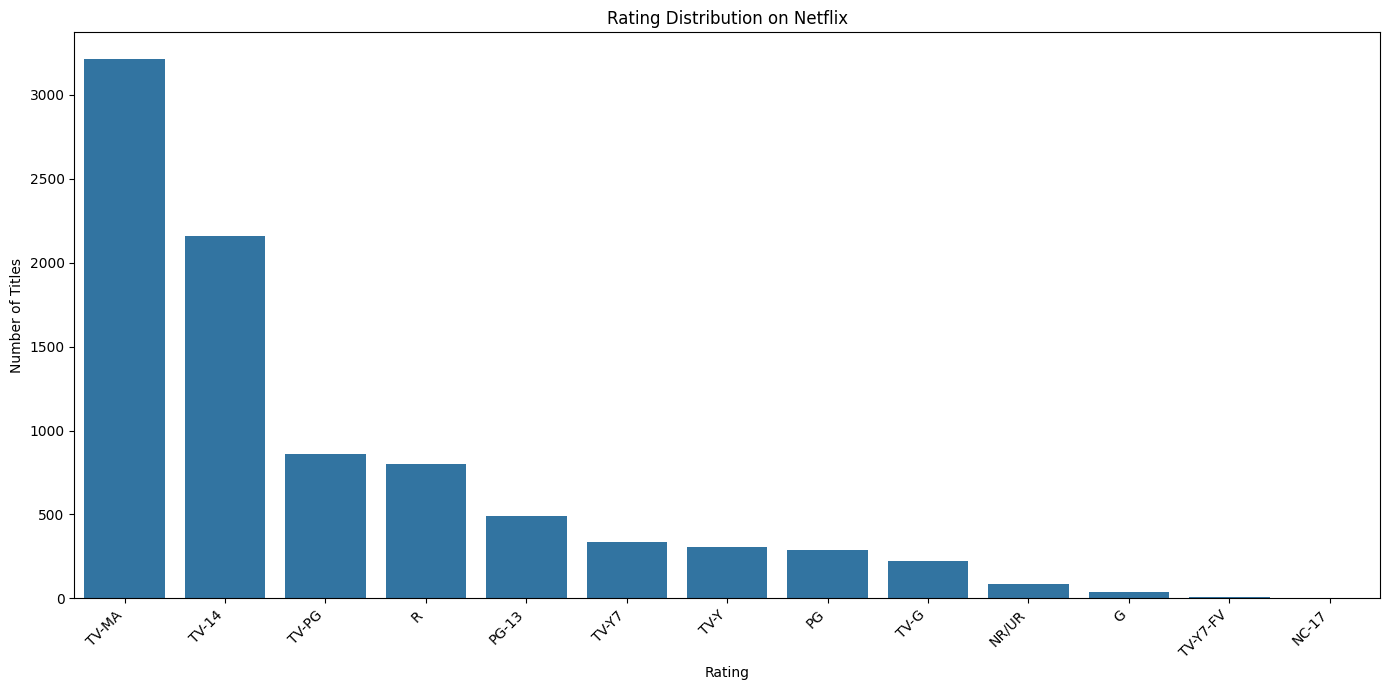

In [25]:
rating_map_reverse = {
    0: 'G',
    1: 'PG',
    2: 'PG-13',
    3: 'R',
    4: 'NC-17',
    5: 'TV-Y',
    6: 'TV-Y7',
    7: 'TV-Y7-FV',
    8: 'TV-G',
    9: 'TV-PG',
    10: 'TV-14',
    11: 'TV-MA',
    12: 'NR/UR'
}
df['rating_label'] = df['rating'].map(rating_map_reverse)

plt.figure(figsize=(14, 7))
sns.countplot(x='rating_label', data=df,
              order=df['rating_label'].value_counts().index)
plt.title('Rating Distribution on Netflix')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

df = df.drop('rating_label', axis=1)

***Netflix Correlation Heatmap***

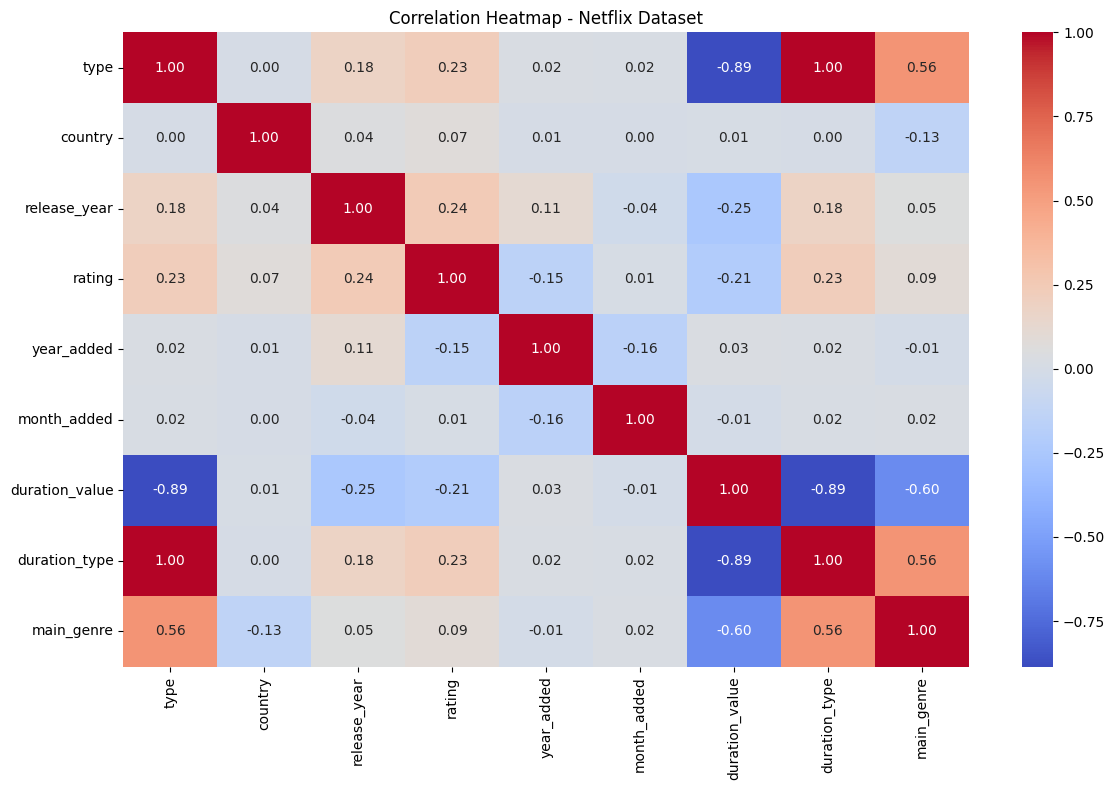

In [26]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Heatmap - Netflix Dataset')
plt.tight_layout()
plt.show()

 ## **Report** 

## Netflix Movies & TV Shows
## Data Preprocessing & EDA

###  Project Overview
This notebook performs complete data 
preprocessing and exploratory data analysis 
on the Netflix Movies and TV Shows dataset
containing 8807 titles.

---

###  Problem Statement
The Netflix dataset contained multiple data 
quality issues including:
- Missing values in key columns
- Inconsistent date formats
- Mixed data in wrong columns
- Text values needing conversion
- Multiple genres in single cells

---

###  Issues Found & Solutions

#### Missing Values
| Column | Missing | Solution |
|--------|---------|----------|
| Director | 2634 (30%) | Dropped |
| Cast | 825 (9%) | Dropped |
| Country | 831 (9%) | Filled with 'Unknown' |
| Date Added | 10 | Filled with mode |
| Rating | 4 | Filled with mode |
| Duration | 3 | Filled with mode |

#### Columns Dropped
- director → 30% missing, not useful
- cast → 9% missing, too complex
- description → just text summary
- show_id → just an ID number

#### Data Type Issues Fixed
- type → Movie/TV Show converted to 0/1
- rating → TV-MA, PG-13 etc to numbers
- country → kept top 10, rest = Other
- duration → split into value and type
- date_added → extracted year and month
- listed_in → extracted main genre only

#### Special Issues Fixed
- Wrong values in rating column
  (74 min, 84 min, 66 min removed)
- Mixed date formats handled
  using format='mixed'
- Kids' TV apostrophe typo fixed

---

###  Key Insights From EDA

#### Content Type
- Netflix has 70% Movies, 30% TV Shows
- Movies dominate the platform!

#### Countries
- United States produces most content
- India is 2nd largest contributor 🇮🇳
- Netflix is heavily US dominated

#### Genres
- Dramas most popular genre (1600 titles)
- Comedies 2nd (1210 titles)
- Action & Adventure 3rd (859 titles)

#### Ratings
- TV-MA most common (3200+ titles)
- Netflix targets adult audience primarily
- Content getting more mature over time

#### Correlations
- type & duration strongly related (-0.89)
- Country doesn't affect other features
- Newer content = slightly mature rating

---

###  Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

###  Dataset Source
Kaggle - Netflix Movies and TV Shows
by Shivam Bansal

###  Author
Student of *BSc Data Science* ***Poulami Bhowmick***